In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_excel("/content/ev_charging_dataset_with_added_parameters (1).xlsx")

In [3]:
data.head(30)

,Station_ID,City,Date,Time_Slot,Vehicle_Type,Battery_Percentage,Charging_Type,Available_Chargers,Vehicles_Waiting,Weather,Temperature,Holiday,Electricity_Load,Waiting_Time,Total_Chargers,Occupied_Chargers,Charging_Power_kW,Traffic_Level
0,S754,Coimbatore,2025-01-13,Evening,SUV,33,Fast,2,21,Rainy,35,Yes,84,205,4,4,120,Medium
1,S130,Coimbatore,2025-04-22,Afternoon,Car,76,Fast,7,7,Cloudy,36,No,30,17,4,1,150,High
2,S814,Hyderabad,2025-06-24,Evening,SUV,32,Normal,2,2,Cloudy,21,No,74,39,8,7,50,Low
3,S370,Coimbatore,2025-08-24,Morning,Van,15,Normal,6,18,Sunny,40,Yes,35,110,6,3,120,Medium
4,S333,Bengaluru,2025-02-10,Afternoon,Car,53,Normal,8,20,Cloudy,23,No,75,85,6,5,150,Low
5,S786,Bengaluru,2025-12-26,Morning,SUV,73,Fast,3,14,Cloudy,26,Yes,71,88,6,6,150,High
6,S334,Coimbatore,2025-06-11,Night,Bike,13,Fast,6,6,Rainy,33,No,88,17,4,0,50,High
7,S371,Chennai,2025-05-07,Evening,Van,79,Normal,6,7,Sunny,34,No,41,35,12,0,150,High
8,S981,Coimbatore,2025-03-20,Afternoon,Van,81,Fast,7,12,Rainy,32,No,100,29,4,0,50,Medium
9,S796,Delhi,2025-02-28,Evening,Bike,19,Normal,7,5,Cloudy,18,No,94,22,12,4,50,High


In [4]:
data.shape

(10000, 18)

In [5]:
data.tail(20)

,Station_ID,City,Date,Time_Slot,Vehicle_Type,Battery_Percentage,Charging_Type,Available_Chargers,Vehicles_Waiting,Weather,Temperature,Holiday,Electricity_Load,Waiting_Time,Total_Chargers,Occupied_Chargers,Charging_Power_kW,Traffic_Level
9980,S883,Mumbai,2025-09-26,Night,Car,57,Normal,1,24,Cloudy,18,Yes,59,835,6,4,150,Medium
9981,S538,Delhi,2025-08-08,Afternoon,Van,38,Normal,7,16,Cloudy,33,No,40,85,6,0,150,Medium
9982,S219,Delhi,2025-01-12,Afternoon,Car,76,Normal,2,6,Rainy,25,Yes,61,109,4,1,120,Low
9983,S432,Hyderabad,2025-12-06,Afternoon,Bike,9,Fast,1,6,Rainy,41,Yes,87,117,6,3,150,Medium
9984,S476,Hyderabad,2025-10-15,Evening,Car,78,Fast,3,12,Sunny,35,Yes,30,76,6,5,150,High
9985,S789,Delhi,2025-02-13,Afternoon,Van,12,Fast,8,25,Rainy,38,Yes,32,67,8,7,120,Low
9986,S157,Coimbatore,2025-05-31,Afternoon,Bike,36,Fast,7,7,Cloudy,19,Yes,91,19,10,10,22,High
9987,S431,Mumbai,2025-03-03,Evening,Van,85,Normal,5,16,Sunny,20,No,91,111,10,8,50,Medium
9988,S838,Delhi,2025-09-15,Evening,Car,21,Fast,1,8,Sunny,41,No,51,155,12,2,22,Medium
9989,S420,Coimbatore,2025-12-11,Morning,Bike,22,Fast,4,13,Sunny,30,Yes,84,64,4,1,50,Medium


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Station_ID          10000 non-null  object
 1   City                10000 non-null  object
 2   Date                10000 non-null  object
 3   Time_Slot           10000 non-null  object
 4   Vehicle_Type        10000 non-null  object
 5   Battery_Percentage  10000 non-null  int64 
 6   Charging_Type       10000 non-null  object
 7   Available_Chargers  10000 non-null  int64 
 8   Vehicles_Waiting    10000 non-null  int64 
 9   Weather             10000 non-null  object
 10  Temperature         10000 non-null  int64 
 11  Holiday             10000 non-null  object
 12  Electricity_Load    10000 non-null  int64 
 13  Waiting_Time        10000 non-null  int64 
 14  Total_Chargers      10000 non-null  int64 
 15  Occupied_Chargers   10000 non-null  int64 
 16  Charging_Power_kW   100

In [7]:
data.drop(["Station_ID"  ,"Date"], axis=1)

,City,Time_Slot,Vehicle_Type,Battery_Percentage,Charging_Type,Available_Chargers,Vehicles_Waiting,Weather,Temperature,Holiday,Electricity_Load,Waiting_Time,Total_Chargers,Occupied_Chargers,Charging_Power_kW,Traffic_Level
0,Coimbatore,Evening,SUV,33,Fast,2,21,Rainy,35,Yes,84,205,4,4,120,Medium
1,Coimbatore,Afternoon,Car,76,Fast,7,7,Cloudy,36,No,30,17,4,1,150,High
2,Hyderabad,Evening,SUV,32,Normal,2,2,Cloudy,21,No,74,39,8,7,50,Low
3,Coimbatore,Morning,Van,15,Normal,6,18,Sunny,40,Yes,35,110,6,3,120,Medium
4,Bengaluru,Afternoon,Car,53,Normal,8,20,Cloudy,23,No,75,85,6,5,150,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Coimbatore,Morning,Van,88,Fast,8,13,Sunny,28,Yes,46,30,4,4,120,Medium
9996,Coimbatore,Afternoon,Car,61,Normal,6,6,Sunny,21,No,75,33,8,8,120,Low
9997,Delhi,Evening,Car,73,Fast,5,17,Sunny,23,Yes,48,72,4,1,50,Low
9998,Mumbai,Evening,SUV,57,Fast,1,12,Sunny,18,Yes,59,238,8,1,120,Low


In [8]:
data.columns

Index(['Station_ID', 'City', 'Date', 'Time_Slot', 'Vehicle_Type',
       'Battery_Percentage', 'Charging_Type', 'Available_Chargers',
       'Vehicles_Waiting', 'Weather', 'Temperature', 'Holiday',
       'Electricity_Load', 'Waiting_Time', 'Total_Chargers',
       'Occupied_Chargers', 'Charging_Power_kW', 'Traffic_Level'],
      dtype='object')

In [9]:
data.describe()

,Battery_Percentage,Available_Chargers,Vehicles_Waiting,Temperature,Electricity_Load,Waiting_Time,Total_Chargers,Occupied_Chargers,Charging_Power_kW
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,49.873600,4.491400,12.477000,30.025300,64.570900,116.587100,8.027000,4.010200,84.899800
std,26.268518,2.299838,7.479242,7.189327,20.439147,139.071857,2.825822,3.079585,51.724144
min,5.000000,1.000000,0.000000,18.000000,30.000000,0.000000,4.000000,0.000000,22.000000
25%,27.000000,2.000000,6.000000,24.000000,47.000000,34.000000,6.000000,2.000000,22.000000
50%,50.000000,4.000000,13.000000,30.000000,64.000000,71.000000,8.000000,3.000000,50.000000
75%,73.000000,7.000000,19.000000,36.000000,82.000000,138.000000,10.000000,6.000000,150.000000
max,95.000000,8.000000,25.000000,42.000000,100.000000,880.000000,12.000000,12.000000,150.000000


In [10]:
data.isnull().sum()

,0
Station_ID,0
City,0
Date,0
Time_Slot,0
Vehicle_Type,0
Battery_Percentage,0
Charging_Type,0
Available_Chargers,0
Vehicles_Waiting,0
Weather,0


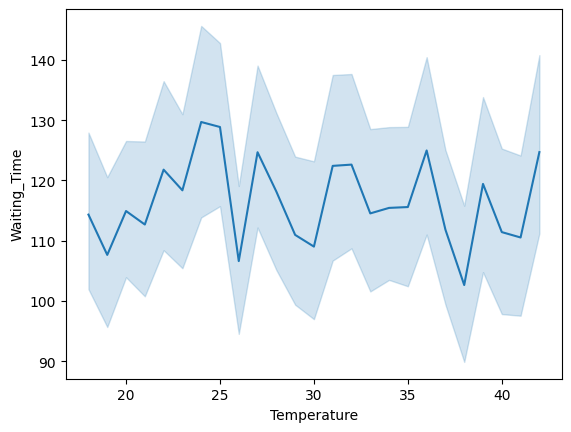

In [11]:
sns.lineplot(x="Temperature", y="Waiting_Time", data=data)
plt.show()

<Axes: xlabel='Waiting_Time'>

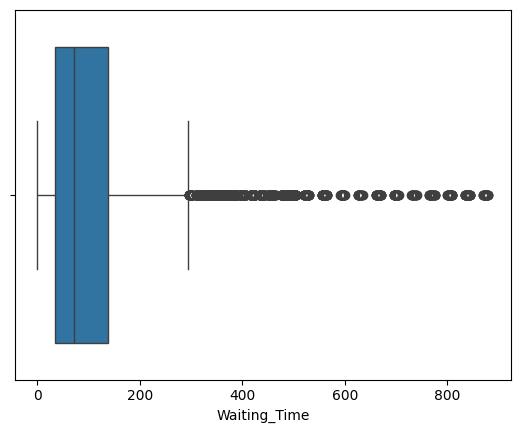

In [12]:
sns.boxplot(x=data["Waiting_Time"])

In [13]:
data ['Waiting_Time']=data['Waiting_Time'].mask(data['Waiting_Time']>500,500 )

In [14]:
data['Charging_Type'] = data['Charging_Type'].map({'Fast': 1, 'Normal': 0})

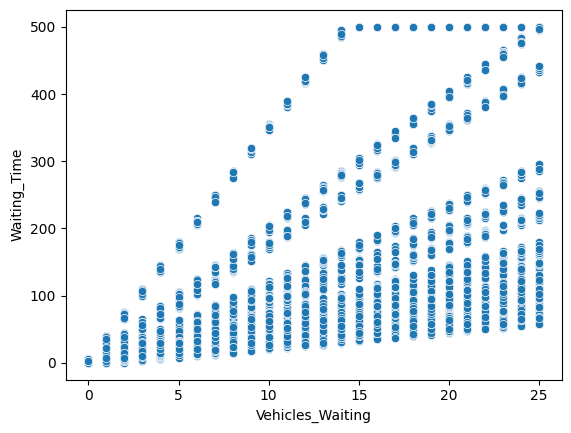

In [15]:
sns.scatterplot(x="Vehicles_Waiting", y="Waiting_Time", data=data)
plt.show()

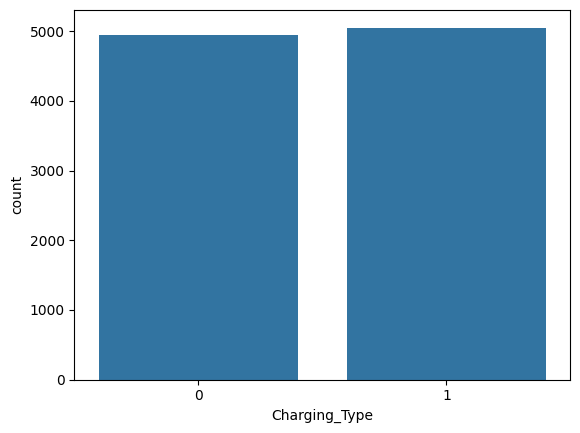

In [16]:
sns.countplot(x="Charging_Type", data=data)
plt.show()

In [17]:
data.corr(numeric_only=True)

,Battery_Percentage,Charging_Type,Available_Chargers,Vehicles_Waiting,Temperature,Electricity_Load,Waiting_Time,Total_Chargers,Occupied_Chargers,Charging_Power_kW
Battery_Percentage,1.000000,0.005358,-0.006807,0.008525,-0.009971,-0.002005,0.010672,0.007610,-0.001113,-0.002479
Charging_Type,0.005358,1.000000,0.006693,0.020398,0.017059,-0.006907,-0.220271,-0.008383,0.005746,0.001753
Available_Chargers,-0.006807,0.006693,1.000000,-0.005273,0.005926,0.004807,-0.606548,-0.009859,-0.012964,0.023916
Vehicles_Waiting,0.008525,0.020398,-0.005273,1.000000,0.001589,-0.014526,0.535013,-0.003004,0.001170,0.008891
Temperature,-0.009971,0.017059,0.005926,0.001589,1.000000,0.006642,-0.005657,0.008542,0.007424,-0.004013
Electricity_Load,-0.002005,-0.006907,0.004807,-0.014526,0.006642,1.000000,0.001894,0.000911,0.004989,0.005382
Waiting_Time,0.010672,-0.220271,-0.606548,0.535013,-0.005657,0.001894,1.000000,0.001439,0.000723,-0.005822
Total_Chargers,0.007610,-0.008383,-0.009859,-0.003004,0.008542,0.000911,0.001439,1.000000,0.463682,0.010576
Occupied_Chargers,-0.001113,0.005746,-0.012964,0.001170,0.007424,0.004989,0.000723,0.463682,1.000000,0.009432
Charging_Power_kW,-0.002479,0.001753,0.023916,0.008891,-0.004013,0.005382,-0.005822,0.010576,0.009432,1.000000


In [18]:
corr_matrix = data.corr(numeric_only=True)
corr_matrix

,Battery_Percentage,Charging_Type,Available_Chargers,Vehicles_Waiting,Temperature,Electricity_Load,Waiting_Time,Total_Chargers,Occupied_Chargers,Charging_Power_kW
Battery_Percentage,1.000000,0.005358,-0.006807,0.008525,-0.009971,-0.002005,0.010672,0.007610,-0.001113,-0.002479
Charging_Type,0.005358,1.000000,0.006693,0.020398,0.017059,-0.006907,-0.220271,-0.008383,0.005746,0.001753
Available_Chargers,-0.006807,0.006693,1.000000,-0.005273,0.005926,0.004807,-0.606548,-0.009859,-0.012964,0.023916
Vehicles_Waiting,0.008525,0.020398,-0.005273,1.000000,0.001589,-0.014526,0.535013,-0.003004,0.001170,0.008891
Temperature,-0.009971,0.017059,0.005926,0.001589,1.000000,0.006642,-0.005657,0.008542,0.007424,-0.004013
Electricity_Load,-0.002005,-0.006907,0.004807,-0.014526,0.006642,1.000000,0.001894,0.000911,0.004989,0.005382
Waiting_Time,0.010672,-0.220271,-0.606548,0.535013,-0.005657,0.001894,1.000000,0.001439,0.000723,-0.005822
Total_Chargers,0.007610,-0.008383,-0.009859,-0.003004,0.008542,0.000911,0.001439,1.000000,0.463682,0.010576
Occupied_Chargers,-0.001113,0.005746,-0.012964,0.001170,0.007424,0.004989,0.000723,0.463682,1.000000,0.009432
Charging_Power_kW,-0.002479,0.001753,0.023916,0.008891,-0.004013,0.005382,-0.005822,0.010576,0.009432,1.000000


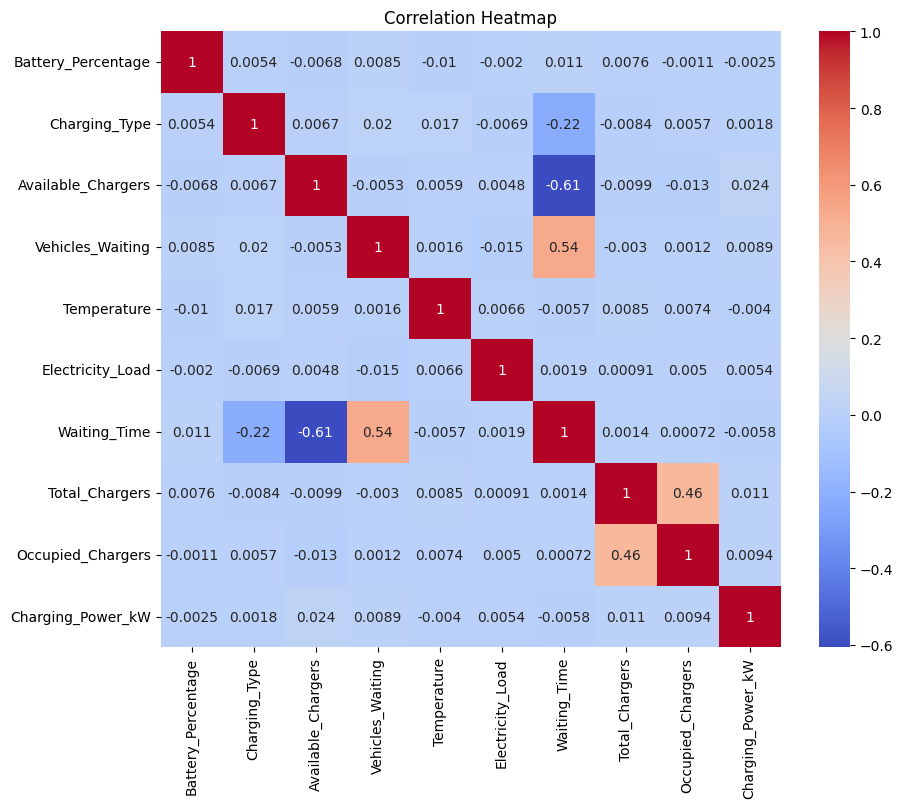

In [33]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [19]:
data=pd.get_dummies(data, drop_first=True)

In [20]:
X = data.drop("Waiting_Time", axis=1)
y = data["Waiting_Time"]

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,random_state=42
)

In [22]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [23]:
y_pred = model.predict(X_test)
print(y_pred)

[266.48204949 273.32292903  77.7599731  ... 217.35922329  90.80607723
  92.4377089 ]


In [24]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 5016.078121071122


In [25]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

R-squared: 0.6481613879290924


In [26]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 54.1084357033702


In [27]:
result = pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
result

,Actual,Predicted
6252,161,266.482049
4684,246,273.322929
1731,75,77.759973
4742,1,-21.382612
4521,232,201.957224
...,...,...
6412,60,28.209701
8285,97,224.085966
7853,162,217.359223
1095,90,90.806077


In [34]:
from sklearn.ensemble import RandomForestRegressor
reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
reg.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, random_state=42)

In [35]:
y_pred = reg.predict(X_test)

In [36]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 10.791248267306637


In [37]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

R-squared: 0.9992430784128077


In [38]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 2.7620611278514593


In [39]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
ridge = Ridge()
parameters = {
    "alpha": [1e-15, 1e-10, 1e-08, 0.0001, 0.001, 0.01, 1, 5, 10, 20, 30]
}
grid = GridSearchCV(ridge, parameters)
grid.fit(X_train, y_train)
best_alpha = grid.best_params_

In [40]:
best_alpha

{'alpha': 30}

In [41]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=best_alpha['alpha'])
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)

In [42]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

R-squared: 0.6927570833383144


In [43]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 4380.288061761009


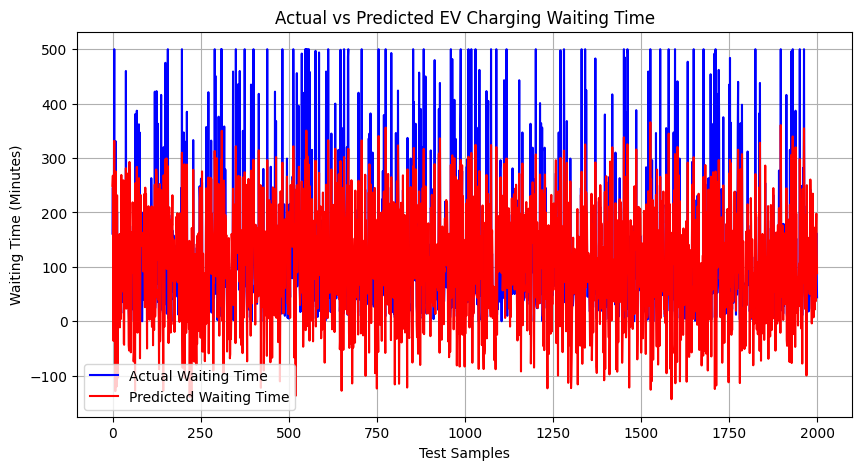

In [44]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Waiting Time", color="blue")
plt.plot(y_pred, label="Predicted Waiting Time", color="red")
plt.title("Actual vs Predicted EV Charging Waiting Time")
plt.xlabel("Test Samples")
plt.ylabel("Waiting Time (Minutes)")
plt.legend()
plt.grid(True)
plt.show()